# Question 1 - Analytical Derivation

## 1. Prediction Distribution of the State

The state prediction model is

\[
x_k^- = A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}
\]

where

\[
x_{k-1}^+ \sim \mathcal N(m_{k-1},P_{k-1})
\]

and

\[
w_{k-1}\sim\mathcal N(0,\Sigma_p)
\]

Since a linear transformation of a Gaussian random variable is also Gaussian,

\[
x_k^- \sim \mathcal N(m_k^-,P_k^-)
\]

The predicted mean is

\[
\begin{aligned}
m_k^-
&=E[x_k^-] \\
&=E[A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}]\\
&=A_{k-1}E[x_{k-1}^+] + G_{k-1}E[w_{k-1}]\\
&=A_{k-1}m_{k-1}
\end{aligned}
\]

because

\[
E[w_{k-1}]=0.
\]

The predicted covariance becomes

\[
\begin{aligned}
P_k^-
&=\text{Cov}(x_k^-)\\
&=\text{Cov}(A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1})\\
&=A_{k-1}P_{k-1}A_{k-1}^T
+G_{k-1}\Sigma_pG_{k-1}^T
\end{aligned}
\]

since the state and process noise are independent.

Therefore,

\[
\boxed{
x_k^- \sim
\mathcal N
\left(
A_{k-1}m_{k-1},
A_{k-1}P_{k-1}A_{k-1}^T
+
G_{k-1}\Sigma_pG_{k-1}^T
\right)
}
\]

---

# 2. Distribution of the Predicted Measurement

The measurement model is

\[
y_k^- = H_kx_k^- + z_k
\]

where

\[
z_k\sim\mathcal N(0,\Sigma_m)
\]

Since both variables are Gaussian,

\[
y_k^- \sim
\mathcal N(H_km_k^-,
H_kP_k^-H_k^T+\Sigma_m)
\]

The mean is

\[
\begin{aligned}
E[y_k^-]
&=E[H_kx_k^-+z_k]\\
&=H_km_k^-.
\end{aligned}
\]

The covariance is

\[
\begin{aligned}
\text{Cov}(y_k^-)
&=H_kP_k^-H_k^T+\Sigma_m.
\end{aligned}
\]

Hence,

\[
\boxed{
y_k^- \sim
\mathcal N
(H_km_k^-,
H_kP_k^-H_k^T+\Sigma_m)
}
\]

---

# 3. Joint Distribution of State and Measurement

The joint Gaussian distribution is

\[
\begin{bmatrix}
x_k^-\\
y_k^-
\end{bmatrix}
\]

whose mean vector is

\[
\begin{bmatrix}
m_k^-\\
H_km_k^-
\end{bmatrix}.
\]

The covariance matrix is

\[
\begin{bmatrix}
P_k^- &
P_k^-H_k^T\\
H_kP_k^- &
H_kP_k^-H_k^T+\Sigma_m
\end{bmatrix}.
\]

Therefore,

\[
\boxed{
\begin{bmatrix}
x_k^-\\
y_k^-
\end{bmatrix}
\sim
\mathcal N
\left(
\begin{bmatrix}
m_k^-\\
H_km_k^-
\end{bmatrix},
\begin{bmatrix}
P_k^- &
P_k^-H_k^T\\
H_kP_k^- &
H_kP_k^-H_k^T+\Sigma_m
\end{bmatrix}
\right)
}
\]

---

# 4. Posterior Distribution

Using the conditional distribution of a multivariate Gaussian,

\[
x_k^+
=
(x_k^-|y_k=y_k^{obs})
\]

is Gaussian.

The Kalman Gain is

\[
K_k=
P_k^-H_k^T
(H_kP_k^-H_k^T+\Sigma_m)^{-1}.
\]

The updated mean becomes

\[
\boxed{
m_k=
m_k^-+
K_k
(y_k^{obs}-H_km_k^-)
}
\]

The updated covariance becomes

\[
\boxed{
P_k=
P_k^-
-
K_kH_kP_k^-
}
\]

or equivalently,

\[
\boxed{
P_k=
(I-K_kH_k)P_k^-.
}
\]

Hence,

\[
\boxed{
x_k^+
\sim
\mathcal N(m_k,P_k)
}
\]

This proves the Kalman Filter prediction and update equations.

Q1 D

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

a = 1.0
h = 1.0
q = 0.2
r = 1.0

m = 0.0
P = 1.0
true_state = 0.0
N = 30

np.random.seed(42)

prior_means = []
prior_vars = []
posterior_means = []
posterior_vars = []
measurements = []
true_states = []

for k in range(N):
    process_noise = np.random.normal(0, np.sqrt(q))
    true_state = a * true_state + process_noise

    measurement_noise = np.random.normal(0, np.sqrt(r))
    y = h * true_state + measurement_noise

    true_states.append(true_state)
    measurements.append(y)

    m_prior = a * m
    P_prior = a * P + q

    S = h * P_prior * h + r
    K = P_prior * h / S

    innovation = y - h * m_prior

    m = m_prior + K * innovation
    P = (1 - K * h) * P_prior

    prior_means.append(m_prior)
    prior_vars.append(P_prior)
    posterior_means.append(m)
    posterior_vars.append(P)

def gaussian(x, mean, var):
    return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-(x - mean) ** 2 / (2 * var))

x = np.linspace(-6, 6, 500)

fig, ax = plt.subplots(figsize=(8,5))

def update(frame):
    ax.clear()

    ax.plot(x, gaussian(x, prior_means[frame], prior_vars[frame]), label="Prior")
    ax.plot(x, gaussian(x, posterior_means[frame], posterior_vars[frame]), label="Posterior")

    ax.axvline(measurements[frame], color='red', linestyle='--', label='Measurement')
    ax.axvline(true_states[frame], color='green', linestyle=':', label='True State')

    ax.set_xlim(-6,6)
    ax.set_ylim(0,1.4)

    ax.set_title(f"Step {frame+1}")
    ax.legend()

ani = FuncAnimation(fig, update, frames=N, interval=600, repeat=False)

plt.close()

HTML(ani.to_jshtml())

In [3]:
print("{:<5}{:<12}{:<12}{:<12}{:<12}".format(
    "Step",
    "Prior",
    "Posterior",
    "Measure",
    "Variance"
))

for i in range(N):
    print("{:<5}{:<12.3f}{:<12.3f}{:<12.3f}{:<12.3f}".format(
        i+1,
        prior_means[i],
        posterior_means[i],
        measurements[i],
        posterior_vars[i]
    ))

Step Prior       Posterior   Measure     Variance    
1    0.000       0.046       0.084       0.545       
2    0.046       0.895       2.035       0.427       
3    0.895       0.617       0.173       0.385       
4    0.617       1.084       1.881       0.369       
5    1.084       1.215       1.446       0.363       
6    1.215       0.860       0.230       0.360       
7    0.860       0.153       -1.109      0.359       
8    0.153       -0.091      -0.529      0.359       
9    -0.091      -0.097      -0.106      0.358       
10   -0.097      -0.864      -2.238      0.358       
11   -0.864      -0.696      -0.396      0.358       
12   -0.696      -1.008      -1.565      0.358       
13   -1.008      -0.744      -0.273      0.358       
14   -0.744      -0.665      -0.523      0.358       
15   -0.665      -0.950      -1.459      0.358       
16   -0.950      -0.460      0.416       0.358       
17   -0.460      -1.191      -2.500      0.358       
18   -1.191      -1.587     

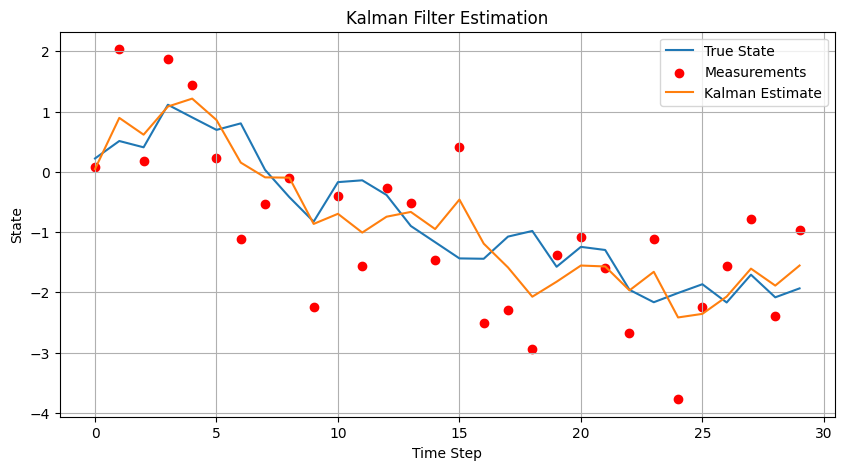

In [4]:
plt.figure(figsize=(10,5))

plt.plot(true_states, label="True State")
plt.scatter(range(N), measurements, color="red", label="Measurements")
plt.plot(posterior_means, label="Kalman Estimate")

plt.xlabel("Time Step")
plt.ylabel("State")
plt.title("Kalman Filter Estimation")

plt.grid(True)
plt.legend()

plt.show()

Q2 Part A

# Q3 - Part A: Derivation of the State-Space Model

The state vector is defined as

\[
x_k=
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
\]

where

- \(p_x(k)\) and \(p_y(k)\) are the position coordinates.
- \(v_x(k)\) and \(v_y(k)\) are the velocity components.

---

## Derivation of the State Transition Matrix \(A\)

Assuming a constant velocity model over a sampling interval \(\Delta t\),

\[
p_x(k)=p_x(k-1)+v_x(k-1)\Delta t,
\]

\[
p_y(k)=p_y(k-1)+v_y(k-1)\Delta t,
\]

Since the velocity is assumed constant,

\[
v_x(k)=v_x(k-1),
\]

\[
v_y(k)=v_y(k-1).
\]

These equations can be written in matrix form as

\[
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1&0&\Delta t&0\\
0&1&0&\Delta t\\
0&0&1&0\\
0&0&0&1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1)\\
p_y(k-1)\\
v_x(k-1)\\
v_y(k-1)
\end{bmatrix}.
\]

Therefore,

\[
\boxed{
A=
\begin{bmatrix}
1&0&\Delta t&0\\
0&1&0&\Delta t\\
0&0&1&0\\
0&0&0&1
\end{bmatrix}
}
\]

---

## Derivation of the Measurement Matrix \(H\)

The GPS sensor measures only the position coordinates.

Therefore,

\[
y_k=
\begin{bmatrix}
p_x(k)\\
p_y(k)
\end{bmatrix}.
\]

Since the velocity components are not measured,

\[
\begin{aligned}
p_x^{meas}(k)&=p_x(k),\\
p_y^{meas}(k)&=p_y(k).
\end{aligned}
\]

Thus,

\[
\begin{bmatrix}
p_x^{meas}(k)\\
p_y^{meas}(k)
\end{bmatrix}
=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0
\end{bmatrix}
x_k.
\]

Hence,

\[
\boxed{
H=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0
\end{bmatrix}
}
\]

---

## Derivation of the Process Noise Matrix \(G\)

Assume that unknown acceleration acts as the process noise.

For motion with constant acceleration,

\[
p=p_0+vt+\frac12at^2,
\]

\[
v=v_0+at.
\]

Let

\[
w=
\begin{bmatrix}
a_x\\
a_y
\end{bmatrix}
\]

represent the acceleration noise.

The position is affected by

\[
\frac12\Delta t^2a,
\]

while the velocity is affected by

\[
\Delta ta.
\]

Therefore,

\[
\begin{bmatrix}
p_x\\
p_y\\
v_x\\
v_y
\end{bmatrix}
=
A x_{k-1}
+
\begin{bmatrix}
\frac12\Delta t^2&0\\
0&\frac12\Delta t^2\\
\Delta t&0\\
0&\Delta t
\end{bmatrix}
w.
\]

Hence,

\[
\boxed{
G=
\begin{bmatrix}
\frac12\Delta t^2&0\\
0&\frac12\Delta t^2\\
\Delta t&0\\
0&\Delta t
\end{bmatrix}
}
\]

---

## Final State-Space Model

The complete linear Gaussian model is

\[
x_k^-
=
Ax_{k-1}^+
+
Gw_{k-1},
\]

\[
y_k
=
Hx_k
+
z_k,
\]

where

\[
w_k\sim\mathcal N(0,\Sigma_p),
\]

\[
z_k\sim\mathcal N(0,\Sigma_m).
\]

Thus, the required matrices are

\[
\boxed{
A=
\begin{bmatrix}
1&0&\Delta t&0\\
0&1&0&\Delta t\\
0&0&1&0\\
0&0&0&1
\end{bmatrix}
}
\]

\[
\boxed{
H=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0
\end{bmatrix}
}
\]

\[
\boxed{
G=
\begin{bmatrix}
\frac12\Delta t^2&0\\
0&\frac12\Delta t^2\\
\Delta t&0\\
0&\Delta t
\end{bmatrix}
}
\]

which are the required state transition, measurement, and process noise matrices for the two-dimensional constant velocity Kalman filter.

Q2 Part B

In [12]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)

dt = 1

A = np.array([
    [1,0,dt,0],
    [0,1,0,dt],
    [0,0,1,0],
    [0,0,0,1]
])

H = np.array([
    [1,0,0,0],
    [0,1,0,0]
])

G = np.array([
    [0.5*dt**2,0],
    [0,0.5*dt**2],
    [dt,0],
    [0,dt]
])

Q = np.array([
    [0.2,0],
    [0,0.2]
])

R = np.array([
    [4,0],
    [0,4]
])

x = np.array([
    [0],
    [0],
    [1],
    [0.6]
])

P = np.eye(4)

steps = 60

true_states = []
measurements = []
estimates = []

true = x.copy()

for i in range(steps):

    w = np.random.multivariate_normal([0,0],Q).reshape(2,1)
    true = A@true + G@w

    z = np.random.multivariate_normal([0,0],R).reshape(2,1)
    y = H@true + z

    x_pred = A@x
    P_pred = A@P@A.T + G@Q@G.T

    S = H@P_pred@H.T + R
    K = P_pred@H.T@np.linalg.inv(S)

    x = x_pred + K@(y-H@x_pred)
    P = (np.eye(4)-K@H)@P_pred

    true_states.append(true[:2].flatten())
    measurements.append(y.flatten())
    estimates.append(x[:2].flatten())

true_states=np.array(true_states)
measurements=np.array(measurements)
estimates=np.array(estimates)

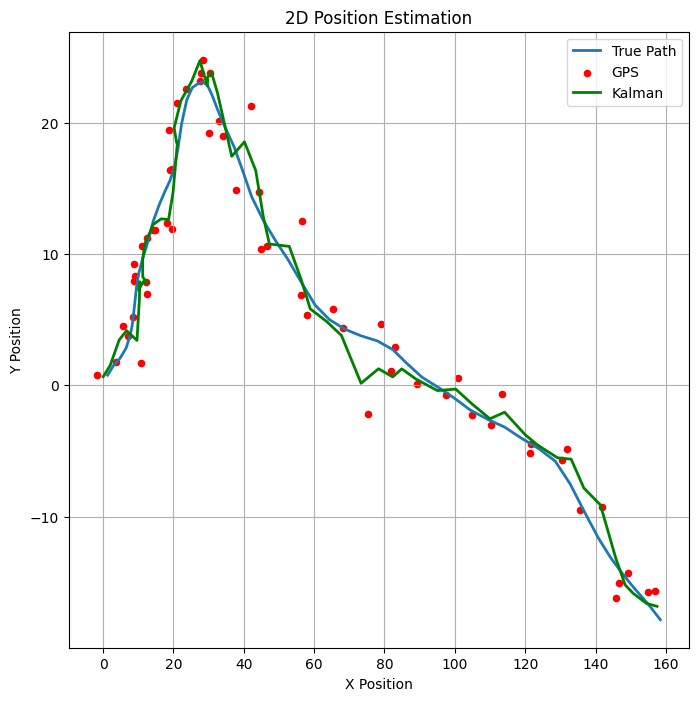

In [9]:
plt.figure(figsize=(8,8))

plt.plot(true_states[:,0],true_states[:,1],label='True Path',linewidth=2)

plt.scatter(measurements[:,0],measurements[:,1],
            color='red',s=20,label='GPS')

plt.plot(estimates[:,0],estimates[:,1],
         color='green',linewidth=2,label='Kalman')

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('2D Position Estimation')

plt.legend()

plt.grid()

plt.show()

In [10]:
error=np.sqrt(np.sum((true_states-estimates)**2,axis=1))

print("Average Position Error :",error.mean())
print("Maximum Position Error :",error.max())
print("Minimum Position Error :",error.min())

Average Position Error : 1.3703275193394746
Maximum Position Error : 3.6158051132851337
Minimum Position Error : 0.24776921919609077


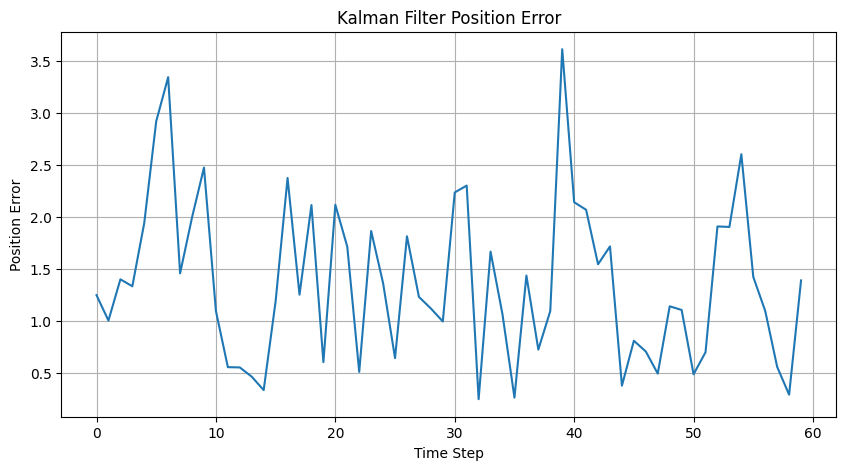

In [11]:
plt.figure(figsize=(10,5))

plt.plot(error)

plt.xlabel("Time Step")

plt.ylabel("Position Error")

plt.title("Kalman Filter Position Error")

plt.grid()

plt.show()